# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
* **Output:** *text cursiv*


# Imports

In [2]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, GroupKFold
from imblearn.over_sampling import SMOTE
from collections import Counter
import time
from scipy.signal import medfilt
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import os
from scipy.stats import zscore

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from scipy.ndimage import uniform_filter1d
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.naive_bayes import GaussianNB

In [3]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/process_dataset'

Mounted at /content/drive


# Datasets

In [4]:
df_train = pd.read_csv(base_path + '/ml_dataset/train_features.csv')
df_val = pd.read_csv(base_path + '/ml_dataset/val_features.csv')

In [5]:
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']

X_val = df_val.drop('Label', axis=1)
y_val = df_val['Label']

## Add only Lag/ Load

In [6]:
def extract_basic_temporal_features(df):
    '''
    Adds temporal context (lag/lead) strictly isolated within each subject's data. This prevents 'data leakage' between different patients.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing multiple subjects.

    Returns:
    - pd.DataFrame: The DataFrame with patient-isolated temporal context.
    '''
    df_new = df.copy()
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']
    cols_to_shift = [c for c in df_new.columns if c not in exclude_cols]

    def shift_group(group):
        for col in cols_to_shift:
            group[f'{col}_lag2'] = group[col].shift(2)
            group[f'{col}_lag1'] = group[col].shift(1)
            group[f'{col}_lead1'] = group[col].shift(-1)
            group[f'{col}_lead2'] = group[col].shift(-2)
        group.bfill(inplace=True)
        group.ffill(inplace=True)
        return group

    return df_new.groupby('Subject_ID', group_keys=False).apply(shift_group, include_groups=False)

df_train_raw_basic = extract_basic_temporal_features(df_train)
df_val_raw_basic = extract_basic_temporal_features(df_val)

X_train_raw_basic = df_train_raw_basic.drop(columns=['Label'])
y_train_raw_basic = df_train_raw_basic['Label']
X_val_raw_basic = df_val_raw_basic.drop(columns=['Label'])
y_val_raw_basic = df_val_raw_basic['Label']

## Normalize Zscore + Lag/ Load

In [7]:
def normalize_by_subject(df, feature_cols):
    '''
    Apply Z-Score normalization per patient (Subject_ID).
    Brings signals from different electrodes (Fpz, C3, C4) to the same common denominator.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - feature_cols (list): List of column names

    Returns:
    - pd.DataFrame: The normalized DataFrame.
    '''
    df_norm = df.copy()
    for col in feature_cols:
        df_norm[col] = df_norm.groupby('Subject_ID')[col].transform(zscore)

    df_norm[feature_cols] = df_norm[feature_cols].fillna(0)
    return df_norm

cols_to_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Mobility', 'Complexity', 'Spectral_Entropy',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

df_train_norm = normalize_by_subject(df_train, cols_to_normalize)
df_val_norm = normalize_by_subject(df_val, cols_to_normalize)
print(f"Shape after: {df_train_norm.shape}")

Shape after: (228213, 22)


In [8]:
df_train_norm_basic = extract_basic_temporal_features(df_train_norm)
df_val_norm_basic = extract_basic_temporal_features(df_val_norm)

df_train_norm_basic['Dataset_Source'] = df_train_norm_basic['Dataset_Source'].astype('category')
df_val_norm_basic['Dataset_Source']   = df_val_norm_basic['Dataset_Source'].astype('category')

X_train_norm_basic = df_train_norm_basic.drop(columns=['Label'])
y_train_norm_basic = df_train_norm_basic['Label']
X_val_norm_basic = df_val_norm_basic.drop(columns=['Label'])
y_val_norm_basic = df_val_norm_basic['Label']

## Temporal feature advances + Z-Score

In [40]:
def extract_enhanced_temporal_features(df):
    '''
    Extract Ratios, Lags, Leads, Diffs and Rolling Stats using ultra-fast vectorized operations, respecting per-patient isolation.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.

    '''
    df_new = df.copy()
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']

    # 1. Creare Ratios (Rapoarte)
    eps = 1e-6
    df_new['Ratio_DeepSleep'] = df_new['Abs_Delta'] / (df_new['Abs_Beta'] + eps)
    df_new['Ratio_Transition'] = df_new['Abs_Theta'] / (df_new['Abs_Alpha'] + eps)

    feature_cols = [c for c in df_new.columns if c not in exclude_cols]
    grouped = df_new.groupby('Subject_ID')[feature_cols]

    # 2. Extragere Lags, Leads și Diferențe vectorizate
    lag1_df = grouped.shift(1).add_suffix('_lag1')
    lag2_df = grouped.shift(2).add_suffix('_lag2')
    lead1_df = grouped.shift(-1).add_suffix('_lead1')
    lead2_df = grouped.shift(-2).add_suffix('_lead2')
    diff_df = df_new[feature_cols].sub(grouped.shift(1)).add_suffix('_diff')

    # 3. Statistici Glisante (Rolling Stats)
    roll_mean_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean()).add_suffix('_roll_mean')
    roll_std_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).std()).add_suffix('_roll_std')

    # 4. Concatenare și curățare NaN-uri
    df_final = pd.concat([df_new, lag1_df, lag2_df, lead1_df, lead2_df, diff_df, roll_mean_df, roll_std_df], axis=1)
    df_final = df_final.groupby('Subject_ID', group_keys=False).apply(lambda g: g.bfill().ffill(), include_groups=False)

    return df_final

df_train_norm_enhanced = extract_enhanced_temporal_features(df_train_norm)
df_val_norm_enhanced   = extract_enhanced_temporal_features(df_val_norm)

# Aici dăm drop și la Subject_ID/Dataset_Source, fiindcă modelele bazate pe arbori (RF/XGBoost) nu au nevoie de ele direct
cols_to_drop = ['Subject_ID', 'Dataset_Source', 'Label']

X_train_norm_enhanced = df_train_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_train_norm_enhanced = df_train_norm_enhanced['Label']
X_val_norm_enhanced   = df_val_norm_enhanced.drop(columns=cols_to_drop, errors='ignore')
y_val_norm_enhanced   = df_val_norm_enhanced['Label']

## Standard Scalar

In [9]:
scaler = StandardScaler()
X_train_std_scalar = scaler.fit_transform(X_train_norm_basic.fillna(0))
X_val_std_scalar = scaler.transform(X_val_norm_basic.fillna(0))

# Generic model functions

## Vitebri

In [24]:
def calculate_transition_matrix(df_train, label_col='Label', subject_col='Subject_ID', n_classes=5):
    '''
    Calculează matricea de tranziție a stadiilor de somn direct din datele de antrenament.
    Se asigură că tranzițiile sunt numărate doar în interiorul înregistrării aceluiași pacient.

    Returnează:
    - trans_mat (np.array): Matrice de dimensiune [n_classes, n_classes] unde
                            rândurile sumează la 1.
    '''
    # Inițializăm matricea cu 1 în loc de 0 (Laplace Smoothing)
    # pentru a evita probabilități absolut zero (care strică logaritmii în Viterbi)
    trans_mat = np.ones((n_classes, n_classes))

    # Grupăm după pacient pentru a evita "data leakage" între pacienți
    for subj, group in df_train.groupby(subject_col):
        labels = group[label_col].values

        # Numărăm de câte ori trecem de la starea i la starea i+1
        for i in range(len(labels) - 1):
            current_state = int(labels[i])
            next_state = int(labels[i+1])
            trans_mat[current_state, next_state] += 1

    # Normalizăm pe rânduri (ca suma probabilităților dintr-o stare către restul să fie 1.0)
    row_sums = trans_mat.sum(axis=1)
    trans_mat = trans_mat / row_sums[:, np.newaxis]

    return trans_mat

In [20]:
def viterbi(obs_probs, trans_mat, start_prob):
    '''
    Algoritmul Viterbi adaptat pentru a găsi cel mai probabil "drum" (secvență de stadii de somn)
    folosind probabilitățile de emisie dintr-un clasificator (ex: Logistic Regression).

    Parametri:
    - obs_probs (np.array): Matrice [n_epoci, n_clase] cu probabilitățile de la model (predict_proba).
    - trans_mat (np.array): Matricea de tranziție [n_clase, n_clase].
    - start_prob (np.array): Probabilitățile inițiale pentru fiecare clasă.

    Returnează:
    - best_path (np.array): Secvența optimă de stadii (drumul cu probabilitatea maximă).
    '''
    n_epochs, n_classes = obs_probs.shape

    # Folosim logaritmi pentru a preveni underflow-ul (1e-10 evită log(0))
    eps = 1e-10
    log_start_prob = np.log(start_prob + eps)
    log_trans_mat = np.log(trans_mat + eps)
    log_obs_probs = np.log(obs_probs + eps)

    # V: Matricea care stochează log-probabilitățile maxime până la pasul t
    V = np.zeros((n_epochs, n_classes))
    # ptr: Matrice pentru a păstra "pointerii" înapoi (de unde am venit pentru a maximiza scorul)
    ptr = np.zeros((n_epochs, n_classes), dtype=int)

    # 1. Inițializare (Pasul 0)
    V[0, :] = log_start_prob + log_obs_probs[0, :]

    # 2. Parcurgere înainte (Forward pass)
    for t in range(1, n_epochs):
        for j in range(n_classes):
            # Scorul pentru a ajunge în starea j la pasul t, venind din fiecare stare la pasul t-1
            seq_probs = V[t-1, :] + log_trans_mat[:, j] + log_obs_probs[t, j]

            # Alegem scorul maxim
            V[t, j] = np.max(seq_probs)
            # Salvăm indexul stării de la pasul t-1 care a dat acest maxim
            ptr[t, j] = np.argmax(seq_probs)

    # 3. Reconstruirea drumului optim (Backward pass)
    best_path = np.zeros(n_epochs, dtype=int)

    # Alegem starea finală cu probabilitatea maximă
    best_path[-1] = np.argmax(V[-1, :])

    # Mergem înapoi pe "pointeri" pentru a găsi tot drumul
    for t in range(n_epochs - 2, -1, -1):
        best_path[t] = ptr[t + 1, best_path[t+1]]

    return best_path

## Temporal Smoothing

In [10]:
def apply_temporal_smoothing(probs, window_size=3):
    return uniform_filter1d(probs, size=window_size, axis=0)

## Train model

In [11]:
def train_model(model, X_train, y_train, X_val, sample_weight=None):
    start_time_fit = time.time()
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)
    print(f"Train time: {(time.time() - start_time_fit):.2f} seconds\n")

    return model.predict(X_val)

## Evaluation table

In [12]:
def create_evaluation_table(y_val, y_pred, df_val = df_val):
  df_eval = pd.DataFrame({
      'Subject_ID': df_val['Subject_ID'],
      'Label': y_val,
      'Pred_Raw': y_pred
  })

  df_eval['Pred_Smooth'] = df_eval.groupby('Subject_ID')['Pred_Raw'].transform(
      lambda x: medfilt(x, kernel_size=3).astype(int)
      )

  return df_eval

## Evaluation model

In [30]:
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

def evaluete_model(y_true, y_pred, class_names=None):
    '''
    Evaluate the performance of a classification model.

    Parameters:
      - y_true (array-like): True labels.
      - y_pred (array-like): Predicted labels.
      - class_names (list): List of class names.
    '''
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy {acc:.4f}\n")

    print("--- Classification report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# Models

## Gaussian Naive Bayes

Train time: 0.12 seconds

Accuracy 0.5795

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.59      0.61      0.60     10361
          N1       0.29      0.19      0.23      6930
          N2       0.63      0.68      0.65     20785
          N3       0.54      0.78      0.64      6474
         REM       0.66      0.43      0.52      7574

    accuracy                           0.58     52124
   macro avg       0.54      0.54      0.53     52124
weighted avg       0.57      0.58      0.57     52124



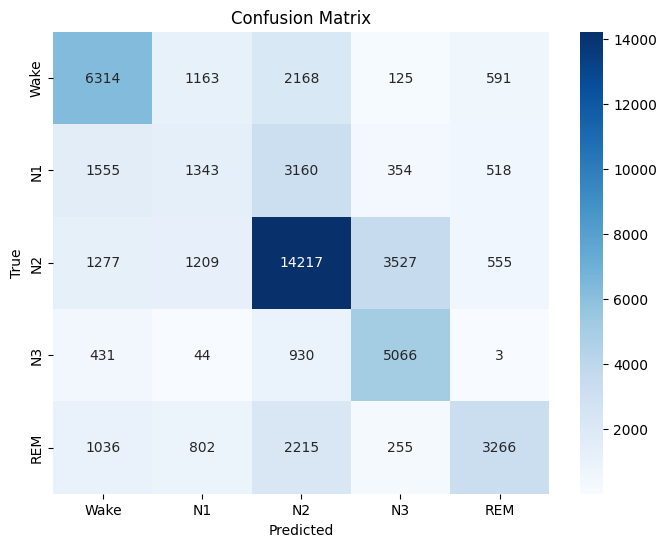

In [37]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt = pt.fit_transform(X_train_norm_basic.fillna(0))
X_val_pt = pt.transform(X_val_norm_basic.fillna(0))

pca_gnb = PCA(n_components=0.95, random_state=42)
X_train_pca_gnb = pca_gnb.fit_transform(X_train_pt)
X_val_pca_gnb = pca_gnb.transform(X_val_pt)

gnb_model = GaussianNB(var_smoothing=1e-5)
y_pred_gnb_raw = train_model(gnb_model, X_train_pca_gnb, y_train_norm_basic, X_val_pca_gnb)

df_eval_gnb = create_evaluation_table(y_val_norm_basic, y_pred_gnb_raw, df_val)

evaluete_model(df_eval_gnb['Label'], df_eval_gnb['Pred_Smooth'], class_names)

Accuracy 0.5948

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.61      0.62      0.61     10361
          N1       0.33      0.16      0.21      6930
          N2       0.62      0.72      0.66     20785
          N3       0.57      0.79      0.66      6474
         REM       0.67      0.46      0.54      7574

    accuracy                           0.59     52124
   macro avg       0.56      0.55      0.54     52124
weighted avg       0.58      0.59      0.58     52124



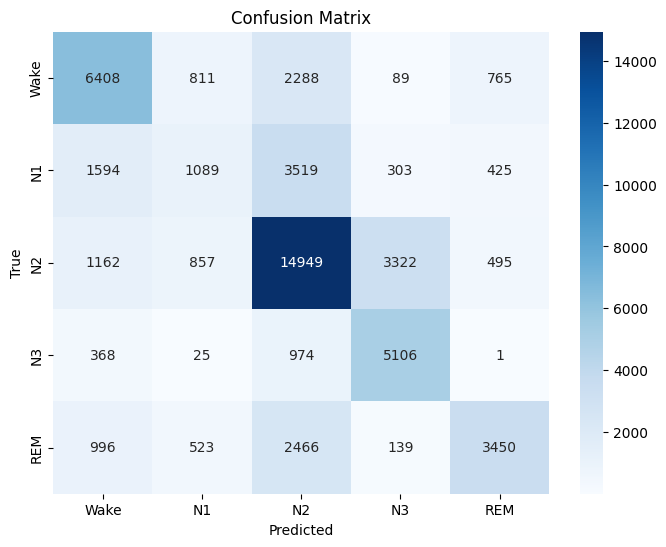

In [38]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt = pt.fit_transform(X_train_norm_basic.fillna(0))
X_val_pt = pt.transform(X_val_norm_basic.fillna(0))

pca_gnb = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_gnb.fit_transform(X_train_pt)
X_val_pca = pca_gnb.transform(X_val_pt)

gnb_model = GaussianNB(var_smoothing=1e-3)
gnb_model.fit(X_train_pca, y_train_norm_basic)

obs_probs = gnb_model.predict_proba(X_val_pca)

trans_mat = calculate_transition_matrix(df_train_norm, label_col='Label', subject_col='Subject_ID')
fair_trans_mat = trans_mat.copy()

for i in range(5):
    fair_trans_mat[i, i] *= 0.8
    fair_trans_mat[i, :] /= fair_trans_mat[i, :].sum()

start_prob = np.array([0.90, 0.02, 0.02, 0.03, 0.03])

df_eval_gnb_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_basic,
    'Pred_HMM': 0
})

for subj in df_eval_gnb_hmm['Subject_ID'].unique():
    idx = df_eval_gnb_hmm['Subject_ID'] == subj
    subj_probs = obs_probs[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_gnb_hmm.loc[idx, 'Pred_HMM'] = best_path

evaluete_model(df_eval_gnb_hmm['Label'], df_eval_gnb_hmm['Pred_HMM'], class_names)

Accuracy 0.5362

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.65      0.28      0.39     10361
          N1       0.28      0.15      0.19      6930
          N2       0.51      0.90      0.65     20785
          N3       0.77      0.57      0.65      6474
         REM       0.70      0.23      0.34      7574

    accuracy                           0.54     52124
   macro avg       0.58      0.42      0.44     52124
weighted avg       0.57      0.54      0.49     52124



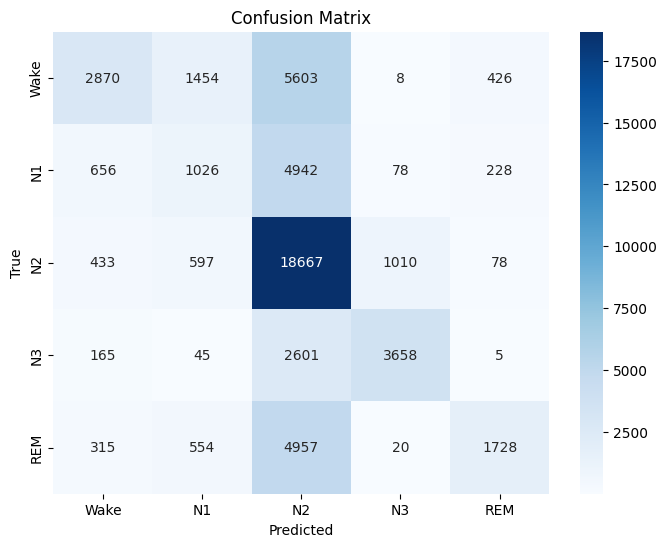

In [43]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_pt = pt.fit_transform(X_train_norm_enhanced.fillna(0))
X_val_pt = pt.transform(X_val_norm_enhanced.fillna(0))

pca_gnb = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_gnb.fit_transform(X_train_pt)
X_val_pca = pca_gnb.transform(X_val_pt)

custom_priors = np.array([0.15, 0.15, 0.30, 0.15, 0.25])

gnb_model = GaussianNB(priors=custom_priors, var_smoothing=1e-3)
gnb_model.fit(X_train_pca, y_train_norm_enhanced)

obs_probs = gnb_model.predict_proba(X_val_pca)

df_eval_gnb_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_gnb_hmm['Subject_ID'].unique():
    idx = df_eval_gnb_hmm['Subject_ID'] == subj
    subj_probs = obs_probs[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_gnb_hmm.loc[idx, 'Pred_HMM'] = best_path

evaluete_model(df_eval_gnb_hmm['Label'], df_eval_gnb_hmm['Pred_HMM'], class_names)

## Logistic Regression

Accuracy 0.6916

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.75      0.76     10361
          N1       0.41      0.28      0.34      6930
          N2       0.78      0.71      0.75     20785
          N3       0.62      0.86      0.72      6474
         REM       0.64      0.79      0.71      7574

    accuracy                           0.69     52124
   macro avg       0.64      0.68      0.65     52124
weighted avg       0.69      0.69      0.68     52124



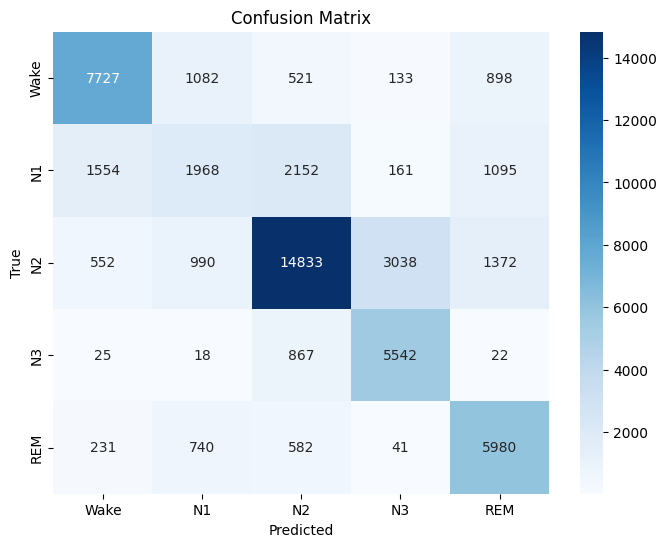

In [46]:
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_norm_enhanced.fillna(0))
X_val_lr_scaled = scaler_lr.transform(X_val_norm_enhanced.fillna(0))

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
lr_model.fit(X_train_lr_scaled, y_train_norm_enhanced)

obs_probs_lr = lr_model.predict_proba(X_val_lr_scaled)

df_eval_lr_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_lr_hmm['Subject_ID'].unique():
    idx = df_eval_lr_hmm['Subject_ID'] == subj
    subj_probs = obs_probs_lr[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_lr_hmm.loc[idx, 'Pred_HMM'] = best_path

evaluete_model(df_eval_lr_hmm['Label'], df_eval_lr_hmm['Pred_HMM'], class_names)

## Linear Discriminant Analysis (LDA)

Accuracy 0.6812

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.69      0.73     10361
          N1       0.48      0.16      0.24      6930
          N2       0.66      0.85      0.75     20785
          N3       0.68      0.68      0.68      6474
         REM       0.69      0.68      0.69      7574

    accuracy                           0.68     52124
   macro avg       0.66      0.61      0.62     52124
weighted avg       0.67      0.68      0.66     52124



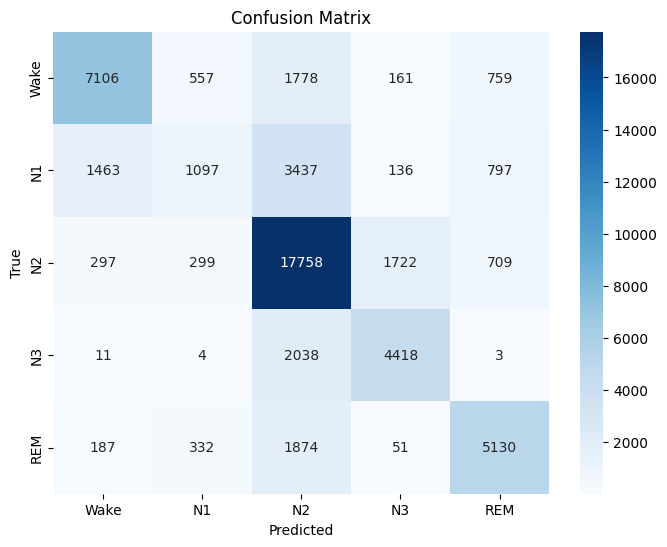

In [48]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

lda_model = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_model.fit(X_train_lr_scaled, y_train_norm_enhanced)

obs_probs_lda = lda_model.predict_proba(X_val_lr_scaled)

df_eval_lda_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_lda_hmm['Subject_ID'].unique():
    idx = df_eval_lda_hmm['Subject_ID'] == subj
    subj_probs = obs_probs_lda[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_lda_hmm.loc[idx, 'Pred_HMM'] = best_path

evaluete_model(df_eval_lda_hmm['Label'], df_eval_lda_hmm['Pred_HMM'], class_names)

## QAD

Accuracy 0.5163

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.32      0.44     10361
          N1       0.31      0.23      0.26      6930
          N2       0.55      0.63      0.59     20785
          N3       0.44      0.88      0.59      6474
         REM       0.56      0.42      0.48      7574

    accuracy                           0.52     52124
   macro avg       0.52      0.50      0.47     52124
weighted avg       0.54      0.52      0.50     52124



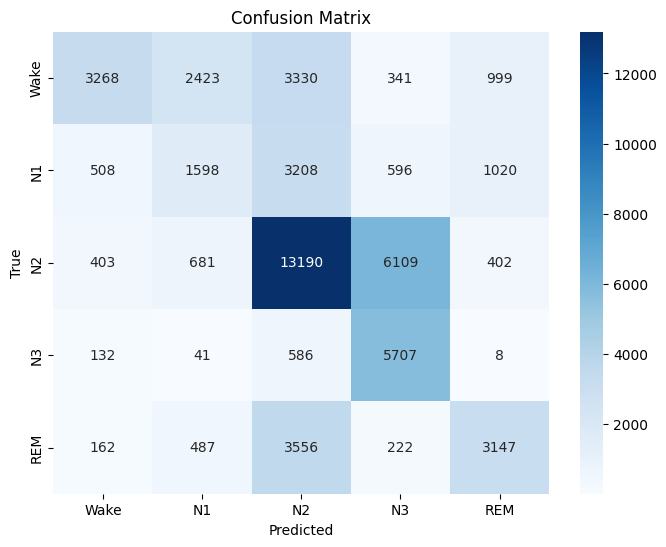

In [51]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import pandas as pd
import numpy as np

qda_model = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda_model.fit(X_train_lr_scaled, y_train_norm_enhanced)

obs_probs_qda = qda_model.predict_proba(X_val_lr_scaled)

df_eval_qda_hmm = pd.DataFrame({
    'Subject_ID': df_val_norm['Subject_ID'],
    'Label': y_val_norm_enhanced,
    'Pred_HMM': 0
})

for subj in df_eval_qda_hmm['Subject_ID'].unique():
    idx = df_eval_qda_hmm['Subject_ID'] == subj
    subj_probs = obs_probs_qda[idx]

    best_path = viterbi(subj_probs, fair_trans_mat, start_prob)
    df_eval_qda_hmm.loc[idx, 'Pred_HMM'] = best_path

evaluete_model(df_eval_qda_hmm['Label'], df_eval_qda_hmm['Pred_HMM'], class_names)

## Ensemble